In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import collections
import random

# --- 1. Wireless Environment Parameters ---
N0_DBM_HZ = -174         # Noise density
P_TX_CLIENT_DBM = 24     # Uplink Power
P_TX_SERVER_DBM = 46     # Downlink Power (Server)
Q_BITS = 16              # 16-bit quantization
RADIUS_KM = 0.5          # 500m
DEVICE_GFLOPS = 2.0      # Average edge device speed

def plot_radar_map(r_km):
    """
    Plots 30 devices in a circular layout with index labels.
    Red triangle = Edge Server (Center)
    Blue dots = Edge Devices (Labeled 0-29)
    """
    # Generate random angles (theta) in radians
    theta = 2 * np.pi * np.random.rand(len(r_km)) 
    
    # Convert polar (r, theta) to Cartesian (x, y) for easier labeling
    x = r_km * np.cos(theta)
    y = r_km * np.sin(theta)
    
    plt.figure(figsize=(8, 8))
    
    # Plot the circular boundary (500m radius)
    circle = plt.Circle((0, 0), RADIUS_KM, color='gray', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)
    
    # Plot Edge Server at the center (0,0)
    plt.scatter(0, 0, c='red', marker='^', s=150, label='Edge Server', zorder=5)
    
    # Plot Edge Devices
    plt.scatter(x, y, c='skyblue', edgecolors='navy', s=80, alpha=0.8, label='Edge Devices')
    
    # Add Index Labels (0 to 29) for each device
    for i in range(len(r_km)):
        plt.annotate(f'{i}', (x[i], y[i]), xytext=(5, 5), 
                     textcoords='offset points', fontsize=9, fontweight='bold')

    plt.title(f"Device Distribution ({RADIUS_KM*1000}m Radius)")
    plt.xlabel("Distance (km)")
    plt.ylabel("Distance (km)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.axis('equal') # Keep the circle from looking like an oval
    plt.xlim(-RADIUS_KM - 0.1, RADIUS_KM + 0.1)
    plt.ylim(-RADIUS_KM - 0.1, RADIUS_KM + 0.1)
    plt.show()

# --- 2. Model Architectures ---
class SVMModel(nn.Module):
    def __init__(self):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(3072, 1)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

# --- 3. Probabilistic Scheduling Logic ---
def get_optimal_probabilities(n_k_list, grad_norms, T_u_list, rho):
    n_total = sum(n_k_list)
    grad_norms = np.array(grad_norms) + 1e-12 
    T_u_list = np.array(T_u_list)
    num_devices = len(n_k_list)

    floor_value = 0.0001 # Each device gets at least 1% chance
    total_floor = num_devices * floor_value
    remaining_budget = 1.0 - total_floor

    def apply_gaussian_top3(values, reverse=False):
        # 1. Start everyone with the 1% floor
        p = np.full(num_devices, floor_value)
        
        # 2. Identify the Top 3
        sorted_indices = np.argsort(values)
        if not reverse:
            sorted_indices = sorted_indices[::-1]
            
        # 3. Distribute the remaining 40% budget using Gaussian weights
        # Weights: Rank1 (1.0), Rank2 (0.606), Rank3 (0.135) -> Sum = 1.741
        raw_weights = np.array([1.0, 0.606, 0.135])
        normalized_weights = raw_weights / np.sum(raw_weights) # Scale to sum to 1.0
        
        # Add the budgeted share to the floor
        p[sorted_indices[0]] += normalized_weights[0] * remaining_budget
        p[sorted_indices[1]] += normalized_weights[1] * remaining_budget
        p[sorted_indices[2]] += normalized_weights[2] * remaining_budget
        
        return p

    # 1. New Behavior for rho = 0 (Channel-aware: Top 3 Fastest)
    if rho == 0:
        return apply_gaussian_top3(T_u_list, reverse=True)

    # 2. New Behavior for rho = 1 (Importance-aware: Top 3 Most Informative)
    if rho == 1:
        # Importance includes data weight n_k/n
        importance = (np.array(n_k_list) / n_total) * grad_norms
        return apply_gaussian_top3(importance, reverse=False)

    # 3. Proposed Policy (Intermediate rho)
    def compute_p_star(lam):
        denom = (1 - rho) * T_u_list + lam
        p = (np.array(n_k_list) / n_total) * grad_norms * np.sqrt(rho / np.maximum(denom, 1e-15))
        return p

    low = -np.min((1 - rho) * T_u_list) + 1e-12
    high = 1e6 
    
    for _ in range(100):
        mid = (low + high) / 2
        if np.sum(compute_p_star(mid)) > 1: low = mid
        else: high = mid

    lambda_star  = high
    final_p_raw = compute_p_star(lambda_star)
    return final_p_raw / np.sum(final_p_raw)

def get_multi_device_selection(n_k_list, grad_norms, T_u_list_full_B, rho, M):
    p_star = get_optimal_probabilities(n_k_list, grad_norms, T_u_list_full_B, rho)
    selected_indices = []
    current_p = p_star.copy()
    for m in range(M):
        current_p = current_p / np.sum(current_p)
        idx = np.random.choice(range(len(p_star)), p=current_p)
        selected_indices.append(idx)
        current_p[idx] = 0
    return selected_indices, p_star

# --- 4. Data Preparation ---

def get_datasets(task='SVM'):
    random.seed(42) 
    np.random.seed(42)

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        
    train_idx = [i for i, l in enumerate(train_set.targets) if l in [0, 1]]
    test_idx = [i for i, l in enumerate(test_set.targets) if l in [0, 1]]
    
    # samples_per_device
    samples = 300 
        
    airplanes = [i for i in train_idx if train_set.targets[i] == 0][:15*samples]
    autos = [i for i in train_idx if train_set.targets[i] == 1][:15*samples]
        
    # Device 0-14 get airplanes, 15-29 get autos
    all_subsets = [Subset(train_set, airplanes[i*samples:(i+1)*samples]) for i in range(15)] + \
                  [Subset(train_set, autos[i*samples:(i+1)*samples]) for i in range(15)]
        
    # RANDOMIZATION: Shuffle so labels are spread 0-29
    random.shuffle(all_subsets)
    device_data = all_subsets
        
    return device_data, Subset(test_set, test_idx), SVMModel(), 0.0001
def plot_radar_map(r_km):
    """
    Plots 30 devices in a circular layout with index labels.
    Red triangle = Edge Server (Center)
    Blue dots = Edge Devices (Labeled 0-29)
    """
    # Generate random angles (theta) in radians
    theta = 2 * np.pi * np.random.rand(len(r_km)) 
    
    # Convert polar (r, theta) to Cartesian (x, y) for easier labeling
    x = r_km * np.cos(theta)
    y = r_km * np.sin(theta)
    
    plt.figure(figsize=(8, 8))
    
    # Plot the circular boundary (500m radius)
    circle = plt.Circle((0, 0), RADIUS_KM, color='gray', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)
    
    # Plot Edge Server at the center (0,0)
    plt.scatter(0, 0, c='red', marker='^', s=150, label='Edge Server', zorder=5)
    
    # Plot Edge Devices
    plt.scatter(x, y, c='skyblue', edgecolors='navy', s=80, alpha=0.8, label='Edge Devices')
    
    # Add Index Labels (0 to 29) for each device
    for i in range(len(r_km)):
        plt.annotate(f'{i}', (x[i], y[i]), xytext=(5, 5), 
                     textcoords='offset points', fontsize=9, fontweight='bold')

    plt.title(f"Device Distribution ({RADIUS_KM*1000}m Radius)")
    plt.xlabel("Distance (km)")
    plt.ylabel("Distance (km)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.axis('equal') # Keep the circle from looking like an oval
    plt.xlim(-RADIUS_KM - 0.1, RADIUS_KM + 0.1)
    plt.ylim(-RADIUS_KM - 0.1, RADIUS_KM + 0.1)
    plt.show()

def run_multi_device_fl_time_constrained(task='SVM', rho=5e-6, M=10, bandwidth=1e6, max_time=5.0, r_km=None):
    device_data, test_set, global_model, lr = get_datasets(task)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)
    n_k_list = [len(d) for d in device_data]
    n_total = sum(n_k_list)
    lmbda = 0.01 
    if r_km is None:
        r_km = RADIUS_KM * np.sqrt(np.random.rand(30)) 
        r_km[:5] = 0.45 + (np.random.rand(5) * 0.05)
        plot_radar_map(r_km)
    history = {'acc': [], 'time': []}
    cumulative_time = 0
    round_count = 0

    print(f"\n--- Simulation: {task} | 30 Clients | {max_time} Seconds ---")

    while cumulative_time < max_time:
        # Communication Model
        path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
        noise_w = 10**(((N0_DBM_HZ + 10 * np.log10(bandwidth)) - 30) / 10)
        p_rx_up_w = 10**(((P_TX_CLIENT_DBM - path_loss_db) - 30) / 10)
        gamma_up = p_rx_up_w / noise_w
        p_rx_down_w = 10**(((P_TX_SERVER_DBM - path_loss_db) - 30) / 10)
        gamma_down_min = np.min(p_rx_down_w / noise_w)
        
        num_params = sum(p.numel() for p in global_model.parameters())
        payload_bits = num_params * Q_BITS
        T_u_full_B = payload_bits / (bandwidth * np.log2(1 + gamma_up))

        # Importance Evaluation
        grad_norms, client_gradients = [], []
        for i in range(30):
            # Step 1: Global Model Broadcast
            local_model = type(global_model)()
            local_model.load_state_dict(global_model.state_dict())
            loader = DataLoader(device_data[i], batch_size=len(device_data[i]))
            data, target = next(iter(loader))
            local_model.zero_grad()

            # Step 2: Local Gradient Calculation
            output = local_model(data).squeeze()
            target_svm = (target.float() * 2) - 1 
            loss = 0.5 * torch.mean(torch.clamp(1 - target_svm * output, min=0)) + (lmbda/2.0) * sum(p.pow(2).sum() for p in local_model.parameters())
            # Step 3: Importance Indicator Report
            loss.backward()
            grads = [p.grad.detach().clone() for p in local_model.parameters()]
            grad_norms.append(torch.norm(torch.cat([g.view(-1) for g in grads])).item())
            client_gradients.append(grads)

        # Step 4: Device Selection and Resource Allocation
        selected_indices, p_star = get_multi_device_selection(n_k_list, grad_norms, T_u_full_B, rho, M)
        
        # Step 5: Local Gradient Upload (Simulate Latency with Bandwidth Allocation - Theorem 3)
        # 1. Calculate the rate per unit bandwidth for selected devices
        R_k = np.log2(1 + gamma_up[selected_indices])
        
        # 2. Apply Theorem 3: Optimal Parallel Upload Time
        # This allows multiple devices to share the 'B' bandwidth efficiently
        sum_sqrt_inv_R = np.sum(np.sqrt(1.0 / R_k))
        t_upload_parallel = (payload_bits / bandwidth) * (sum_sqrt_inv_R**2)
        
        # 3. Standard overheads
        t_broadcast = payload_bits / (bandwidth * np.log2(1 + gamma_down_min))
        t_comp_max = (max(n_k_list) * 6000) / (DEVICE_GFLOPS * 1e9)
        
        # Total time for this specific round
        round_time = t_broadcast + t_comp_max + t_upload_parallel
        cumulative_time += round_time
        round_count += 1

        # Step 6: Global Model Update (Equation 29)
        with torch.no_grad():
            global_grad_sum = [torch.zeros_like(p) for p in global_model.parameters()]
            
            for m, idx in enumerate(selected_indices):
                if rho == 0 or rho == 1:
                    # --- FedAvg Style (Simple Average) ---
                    # We ignore the selection probability scaling entirely.
                    # Each of the M selected devices contributes 1/M to the update.
                    for g_sum, g_local in zip(global_grad_sum, client_gradients[idx]):
                        g_sum += (1.0 / M) * g_local
                else:
                    # --- Proposed Policy Style (Unbiased Estimator) ---
                    # Calculate conditional probability q_Y_m for Theorem 1 correctness
                    sum_prev_p = sum(p_star[selected_indices[j]] for j in range(m))
                    q_Y_m = p_star[idx] / np.maximum(1.0 - sum_prev_p, 1e-10)
                    
                    # Apply importance scale based on Equation 29
                    scale = n_k_list[idx] / (n_total * q_Y_m)
                    
                    for g_sum, g_local in zip(global_grad_sum, client_gradients[idx]):
                        # Clip only the proposed update to handle potential variance
                        update_val = (1.0 / M) * scale * g_local
                        g_sum += torch.clamp(update_val, min=-10.0, max=10.0)
            
            # Update global weights
            for p_global, g_agg in zip(global_model.parameters(), global_grad_sum):
                p_global -= lr * g_agg

        # Evaluation
        global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = global_model(data)
                correct += (torch.sign(output.squeeze()) == (target.float()*2-1)).sum().item()
                total += target.size(0)
        
        acc = 100. * correct / total
        history['acc'].append(acc)
        history['time'].append(cumulative_time)
        
        if round_count % 5 == 0:
            print(f"M={M} | Time: {cumulative_time:.2f}s / {max_time}s | Acc: {history['acc'][-1]:.4f}")

    return history

def run_fig5_comparison_fixed_time(bandwidth_list=[1e6, 20e6], time_limits={1e6: 300.0, 20e6: 30.0}):
    M_values = [1, 10, 20, 30]
    rho = 5e-5
    all_results = {b: {} for b in bandwidth_list}

    # 1. Run Simulation
    for B_val in bandwidth_list:
        # Get the specific limit for this B, default to 5.0 if not provided
        limit = time_limits.get(B_val, 5.0)
        r_km = RADIUS_KM * np.sqrt(np.random.rand(30)) 
        r_km[:5] = 0.45 + (np.random.rand(5) * 0.05)
        plot_radar_map(r_km)

        for M in M_values:
            print(f"\n>>> Running: B={B_val/1e6}MHz, M={M}, Limit={limit}s")
            all_results[B_val][M] = run_multi_device_fl_time_constrained(
                rho=rho, M=M, bandwidth=B_val, max_time=limit, r_km=r_km
            )

    # 2. Dynamic Plotting
    num_plots = len(bandwidth_list)
    fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 6), squeeze=False)
    
    for i, B_val in enumerate(bandwidth_list):
        ax = axes[0, i]
        limit = time_limits.get(B_val, 5.0)
        
        for M in M_values:
            res = all_results[B_val][M]
            # Plot Accuracy over Time
            ax.plot(res['time'], res['acc'], label=f'M={M}')
        
        ax.set_title(f"Bandwidth = {B_val/1e6} MHz (Total Time: {limit}s)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xlim(-limit*0.05, limit*1.05) # Clean margins for the x-axis
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# To run both: run_fig5_comparison_fixed_time(bandwidth_list=[1e6, 20e6], time_limits={1e6: 300.0, 20e6: 30.0})
# To run only 20 MHz: run_fig5_comparison_fixed_time(bandwidth_list=[20e6], time_limits={20e6: 10.0})


>>> Running: B=1.0MHz, M=1, Target Time=300s
Files already downloaded and verified
Files already downloaded and verified

--- Simulation: SVM | 30 Clients | 300 Seconds ---
M=1 | Time: 0.04s / 300s | Acc: 65.6000
M=1 | Time: 0.08s / 300s | Acc: 65.6500
M=1 | Time: 0.12s / 300s | Acc: 66.3500
M=1 | Time: 0.15s / 300s | Acc: 66.3500
M=1 | Time: 0.20s / 300s | Acc: 67.0000
M=1 | Time: 0.23s / 300s | Acc: 67.4000
M=1 | Time: 0.27s / 300s | Acc: 67.4000
M=1 | Time: 0.31s / 300s | Acc: 67.4500
M=1 | Time: 0.34s / 300s | Acc: 67.5500
M=1 | Time: 0.38s / 300s | Acc: 67.5500
M=1 | Time: 0.42s / 300s | Acc: 68.1000
M=1 | Time: 0.46s / 300s | Acc: 68.3000
M=1 | Time: 0.49s / 300s | Acc: 68.3500
M=1 | Time: 0.53s / 300s | Acc: 69.0000
M=1 | Time: 0.57s / 300s | Acc: 69.1000
M=1 | Time: 0.61s / 300s | Acc: 69.1000
M=1 | Time: 0.64s / 300s | Acc: 69.0000
M=1 | Time: 0.68s / 300s | Acc: 69.4000
M=1 | Time: 0.72s / 300s | Acc: 69.4500
M=1 | Time: 0.76s / 300s | Acc: 69.4500
M=1 | Time: 0.80s / 300s |

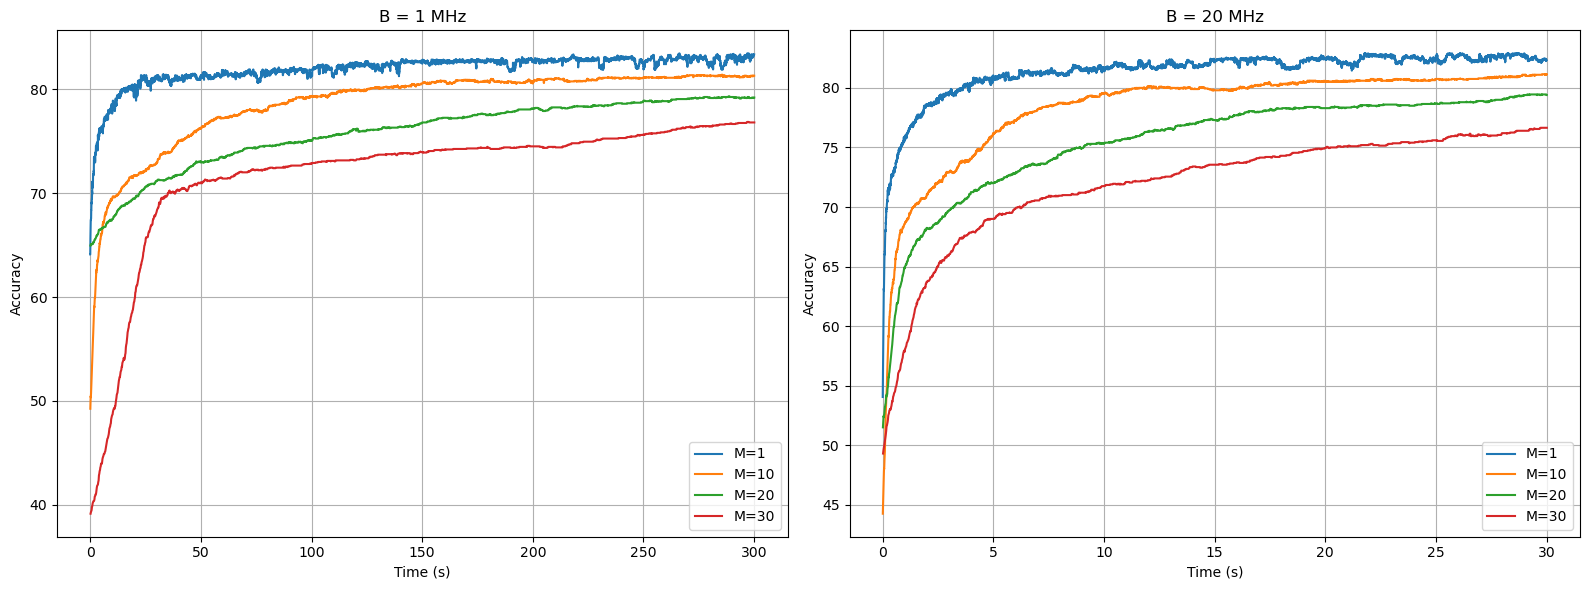

In [3]:
run_fig5_comparison_fixed_time(max_time_1mhz = 300, max_time_20mhz = 30)

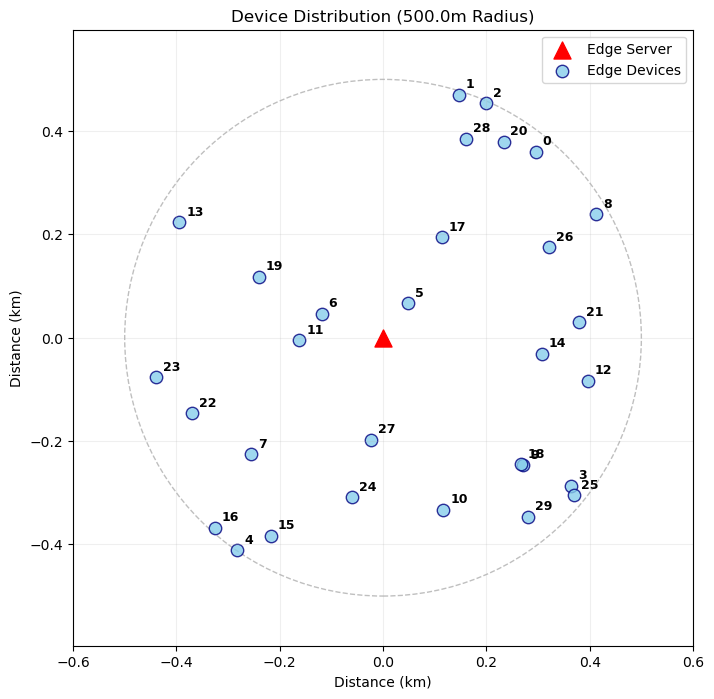


>>> Running: B=20.0MHz, M=1, Limit=30.0s
Files already downloaded and verified
Files already downloaded and verified

--- Simulation: SVM | 30 Clients | 30.0 Seconds ---
M=1 | Time: 0.01s / 30.0s | Acc: 34.9000
M=1 | Time: 0.02s / 30.0s | Acc: 35.0000
M=1 | Time: 0.02s / 30.0s | Acc: 35.9000
M=1 | Time: 0.03s / 30.0s | Acc: 36.3500
M=1 | Time: 0.04s / 30.0s | Acc: 37.4000
M=1 | Time: 0.05s / 30.0s | Acc: 37.9000
M=1 | Time: 0.06s / 30.0s | Acc: 38.9000
M=1 | Time: 0.07s / 30.0s | Acc: 40.3000
M=1 | Time: 0.08s / 30.0s | Acc: 41.6500
M=1 | Time: 0.09s / 30.0s | Acc: 43.4500
M=1 | Time: 0.09s / 30.0s | Acc: 45.7500
M=1 | Time: 0.10s / 30.0s | Acc: 47.6000
M=1 | Time: 0.11s / 30.0s | Acc: 49.6000
M=1 | Time: 0.12s / 30.0s | Acc: 51.3000
M=1 | Time: 0.13s / 30.0s | Acc: 53.4000
M=1 | Time: 0.14s / 30.0s | Acc: 55.6000
M=1 | Time: 0.15s / 30.0s | Acc: 57.1500
M=1 | Time: 0.15s / 30.0s | Acc: 58.4000
M=1 | Time: 0.16s / 30.0s | Acc: 59.4500
M=1 | Time: 0.17s / 30.0s | Acc: 60.8000
M=1 | Tim

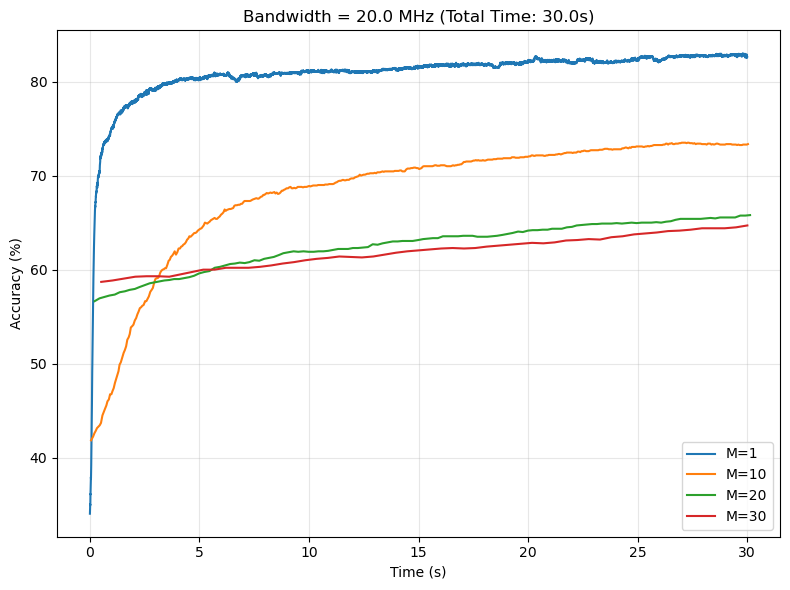

In [17]:
run_fig5_comparison_fixed_time(bandwidth_list=[20e6], time_limits={20e6: 30.0})